In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import csv
import os

In [2]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, path='best_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        # كيسجل الموديل ملي كتكون أحسن نتيجة
        torch.save(model.state_dict(), self.path)
        print("Best model saved!")

In [11]:
# الدوسي فين حاط التصاور
data_dir = r".\PlantVillage"

In [ ]:
# نوجدو التصاور (Resize & Normalize) باش يوافقو ResNet50
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(), # قلب التصويرة أفقيا
    transforms.RandomRotation(20),     # تدوير التصويرة شوية
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [12]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [15]:
# عدد الأمراض (Classes)
class_names = dataset.classes
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(pretrained=True)
# 2. تجميد كل الطبقات (باش ما يتبدلوش الأوزان ديالهم)
for param in model.parameters():
    param.requires_grad = False
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names)) # 15 كلاس اللي بقاو عندك
model = model.to(device)

In [ ]:
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

In [10]:
# 3. إعداد الـ CSV Logger
csv_file = './History/training_history.csv'
with open(csv_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Epoch', 'Train Loss', 'Train Accuracy', 'Val Loss', 'Val Accuracy'])

In [11]:
# 4. التدريب مع tqdm و Early Stopping
num_epochs = 20
early_stopping = EarlyStopping(patience=3, path='./Models/best_plant_resnet50.pth')

In [12]:
for epoch in range(num_epochs):
    # --- مرحلة التدريب (Train) ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    # tqdm باش يبان البار
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # حساب المتغيرات
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # تحديث قيمة Loss فالشريط
        train_bar.set_postfix(loss=loss.item())
        
    train_loss = running_loss / train_size
    train_acc = 100 * correct / total

    # --- مرحلة التقييم (Validation) ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            val_bar.set_postfix(loss=loss.item())
            
    val_loss = val_loss / val_size
    val_acc = 100 * val_correct / val_total
    
    # 5. تسجيل النتائج فـ CSV Logger
    with open(csv_file, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([epoch+1, train_loss, train_acc, val_loss, val_acc])
        
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # 6. التحقق من الـ Early Stopping
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered! Training stopped.")
        break

Epoch 1/20 [Val]: 100%|██████████| 129/129 [00:28<00:00,  4.59it/s, loss=0.232]


Train Loss: 0.5196 | Train Acc: 83.21% | Val Loss: 0.3838 | Val Acc: 86.75%
Best model saved!


Epoch 2/20 [Val]: 100%|██████████| 129/129 [00:22<00:00,  5.66it/s, loss=0.157] 


Train Loss: 0.2233 | Train Acc: 92.62% | Val Loss: 0.1709 | Val Acc: 94.57%
Best model saved!


Epoch 3/20 [Val]: 100%|██████████| 129/129 [00:22<00:00,  5.80it/s, loss=0.275] 


Train Loss: 0.1797 | Train Acc: 94.26% | Val Loss: 0.1784 | Val Acc: 94.33%
EarlyStopping counter: 1 out of 3


Epoch 4/20 [Val]: 100%|██████████| 129/129 [00:22<00:00,  5.83it/s, loss=0.155] 


Train Loss: 0.1289 | Train Acc: 95.80% | Val Loss: 0.1760 | Val Acc: 93.77%
EarlyStopping counter: 2 out of 3


Epoch 5/20 [Val]: 100%|██████████| 129/129 [00:20<00:00,  6.25it/s, loss=0.0444]

Train Loss: 0.0926 | Train Acc: 96.93% | Val Loss: 0.2239 | Val Acc: 93.00%
EarlyStopping counter: 3 out of 3
Early stopping triggered! Training stopped.


In [13]:
print("Training completed! Check 'training_history.csv' for logs.")

Training completed! Check 'training_history.csv' for logs.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# قراءة البيانات من ملف CSV
df = pd.read_csv('./History/training_history.csv')

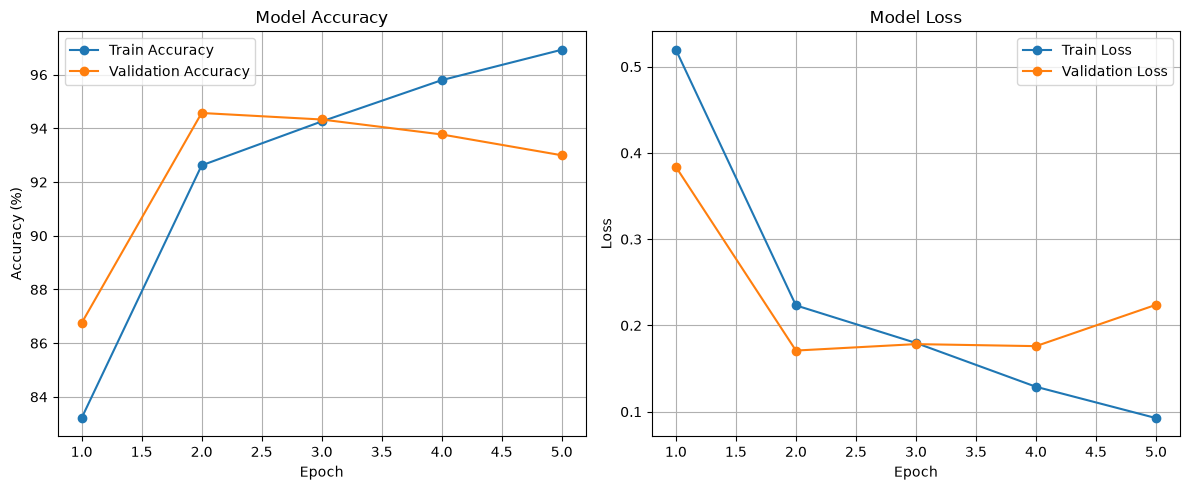

In [4]:
plt.figure(figsize=(12, 5))

# مبيان الدقة (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(df['Epoch'], df['Train Accuracy'], label='Train Accuracy', marker='o')
plt.plot(df['Epoch'], df['Val Accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# مبيان الخسارة (Loss)
plt.subplot(1, 2, 2)
plt.plot(df['Epoch'], df['Train Loss'], label='Train Loss', marker='o')
plt.plot(df['Epoch'], df['Val Loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
# 2. إرسال الموديل إلى الجهاز المناسب
model = model.to(device)

In [18]:
# تأكد أن الموديل فوضع التقييم
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [19]:

all_preds = []
all_labels = []

In [20]:
# ما كنحتاجوش نحسبو الـ Gradients هنا
with torch.no_grad():
    for images, labels in val_loader: # كنستعملو val_loader حيت الموديل ماتدربش عليه
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        # كنزيدو النتائج فـ lists باش نخدمو بيهم من بعد
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [21]:
# كنجبدو السميات ديال الكلاسات من dataset (نفس الترتيب)
class_names = dataset.classes

In [22]:
# 5. رسم مصفوفة الارتباك (Confusion Matrix)
cm = confusion_matrix(all_labels, all_preds)

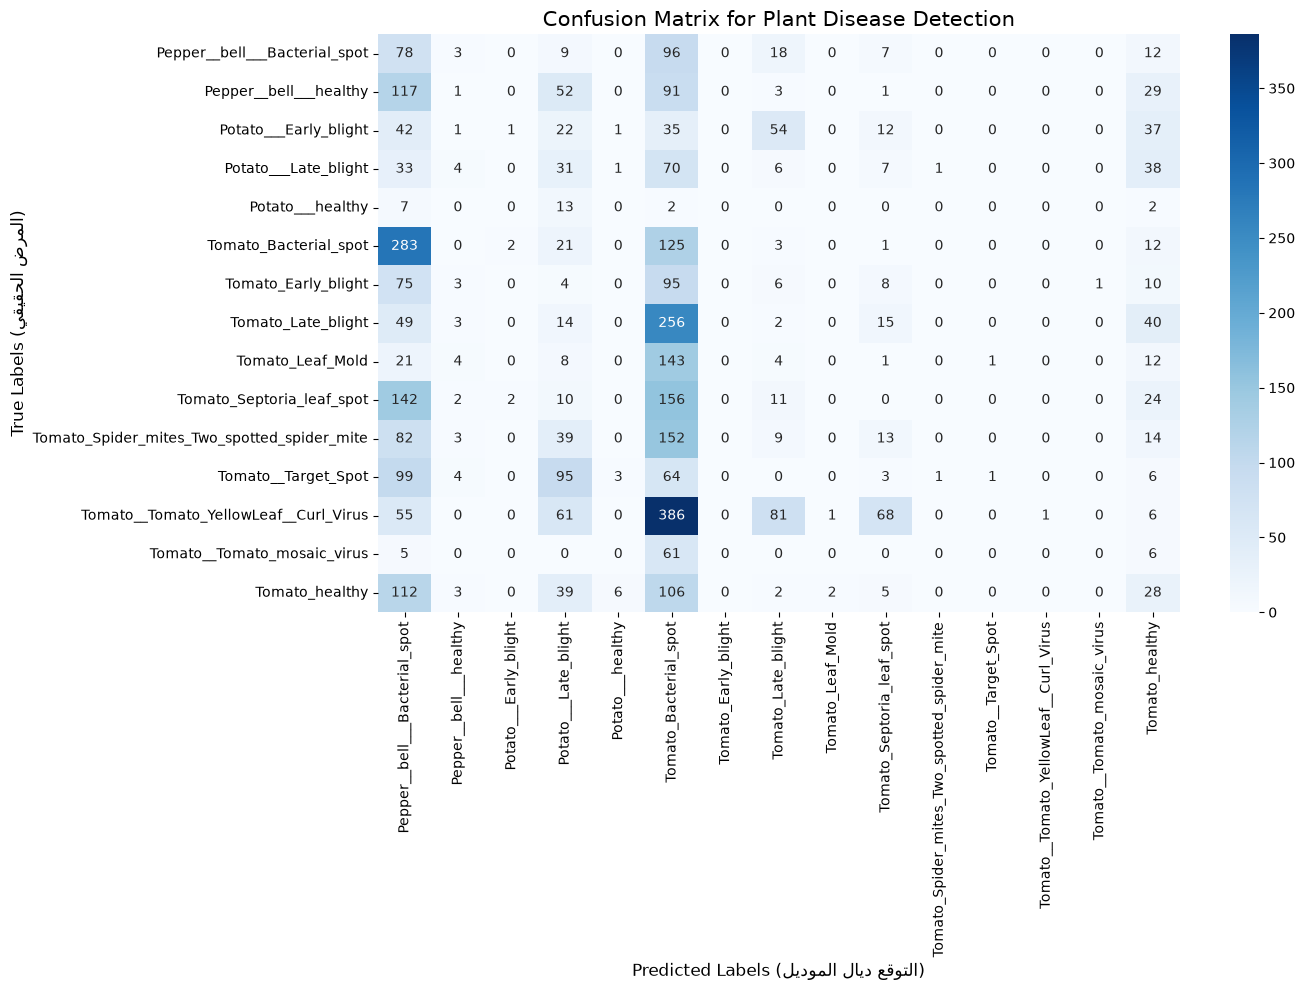

In [23]:
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Labels (التوقع ديال الموديل)', fontsize=12)
plt.ylabel('True Labels (المرض الحقيقي)', fontsize=12)
plt.title('Confusion Matrix for Plant Disease Detection', fontsize=15)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [24]:
# 6. طباعة تقرير التصنيف (Classification Report)
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.07      0.35      0.11       223
                     Pepper__bell___healthy       0.03      0.00      0.01       294
                      Potato___Early_blight       0.20      0.00      0.01       205
                       Potato___Late_blight       0.07      0.16      0.10       191
                           Potato___healthy       0.00      0.00      0.00        24
                      Tomato_Bacterial_spot       0.07      0.28      0.11       447
                        Tomato_Early_blight       0.00      0.00      0.00       202
                         Tomato_Late_blight       0.01      0.01      0.01       379
                           Tomato_Leaf_Mold       0.00      0.00      0.00       194
                  Tomato_Septoria_leaf_spot       0.00      0.00      0.00       347
Tomato_Spider_mites_Two_spotted_spider_m

c:\Users\Demahom\anaconda3\envs\plant_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Demahom\anaconda3\envs\plant_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Demahom\anaconda3\envs\plant_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}